In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv('C:/Users/Administrator/Documents/projectsML/ML/data/raw/ai4i2020.csv')

# Affichage des 5 premières lignes par defaut
print(df.head())

   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0    0  
1    0    0    0    0  
2    0  

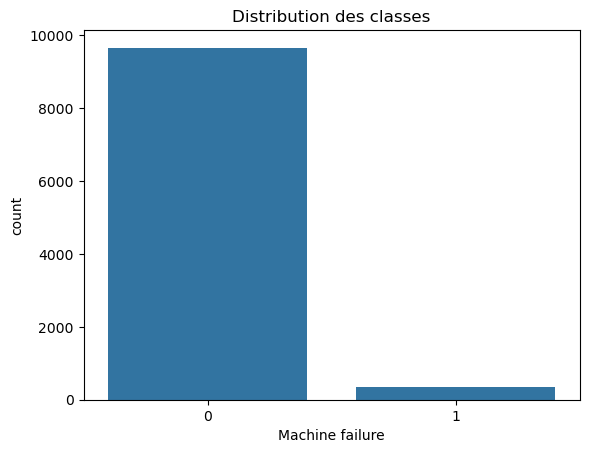

In [4]:
#Visualisation du déséquilibre
sns.countplot(x='Machine failure', data=df)
plt.title('Distribution des classes')
plt.show()

In [5]:
#Suppression des colonnes inutiles

df = df.drop(columns=['UDI', 'Product ID'])

print(df.head())

  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0                9                0    0    0    0    0    0  


In [6]:
#Encodage de la variable Type
mapping = {
    'L': 0,
    'M': 1,
    'H': 2
}


df['Type'] = df['Type'].map(mapping)

print(df.head())

   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     1                298.1                    308.6                    1551   
1     0                298.2                    308.7                    1408   
2     0                298.1                    308.5                    1498   
3     0                298.2                    308.6                    1433   
4     0                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Machine failure  TWF  HDF  PWF  OSF  RNF  
0         42.8                0                0    0    0    0    0    0  
1         46.3                3                0    0    0    0    0    0  
2         49.4                5                0    0    0    0    0    0  
3         39.5                7                0    0    0    0    0    0  
4         40.0                9                0    0    0    0    0    0  


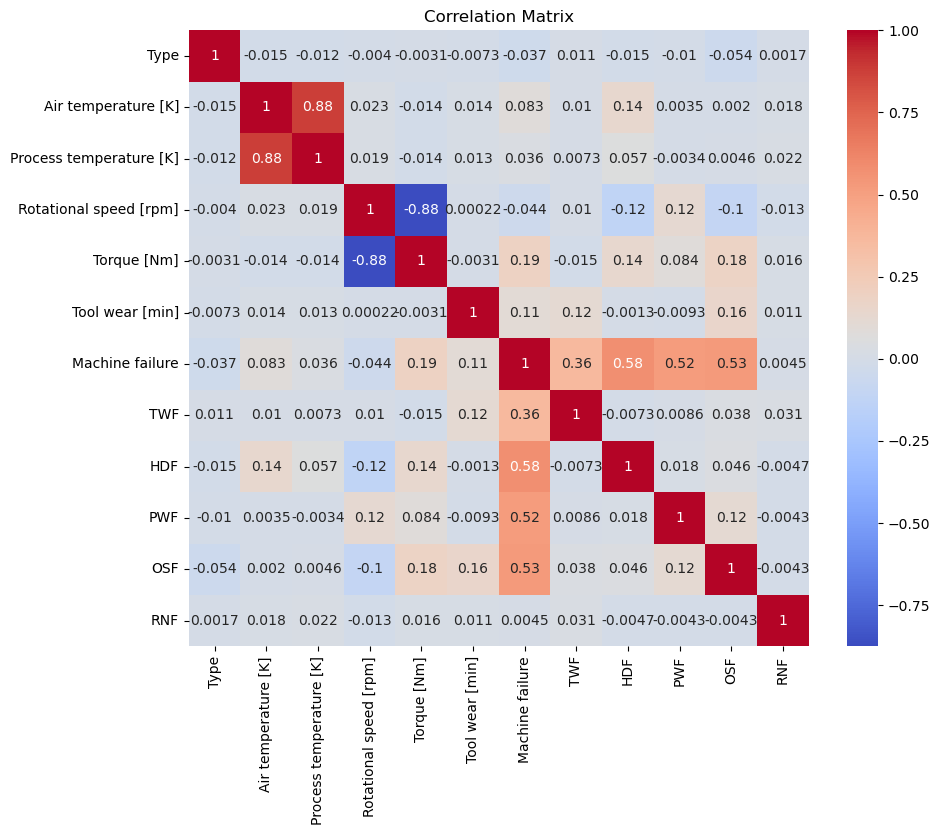

In [7]:
#Matrice de corrélation
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()

In [8]:
#Séparation Features / Target
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

In [9]:
#step1
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)
#step2
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [10]:
#normalisation
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [11]:
#smote
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [12]:
#smote verification
print("Avant SMOTE:")
print(y_train.value_counts())

print("\nAprès SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Avant SMOTE:
Machine failure
0    6763
1     237
Name: count, dtype: int64

Après SMOTE:
Machine failure
0    6763
1    6763
Name: count, dtype: int64


In [16]:
#conversion en dataframe
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [19]:
#data downloading 
# Sauvegarde des features
X_train_resampled.to_csv('C:/Users/Administrator/Documents/projectsML/ML/data/processed/X_train.csv', index=False)
X_val_scaled.to_csv('C:/Users/Administrator/Documents/projectsML/ML/data/processed/X_val.csv', index=False)
X_test_scaled.to_csv('C:/Users/Administrator/Documents/projectsML/ML/data/processed/X_test.csv', index=False)

# Sauvegarde des labels
pd.DataFrame(y_train_resampled).to_csv('C:/Users/Administrator/Documents/projectsML/ML/data/processed/y_train.csv', index=False)
pd.DataFrame(y_val).to_csv('C:/Users/Administrator/Documents/projectsML/ML/data/processed/y_val.csv', index=False)
pd.DataFrame(y_test).to_csv('C:/Users/Administrator/Documents/projectsML/ML/data/processed/y_test.csv', index=False)

In [20]:
print("Préprocessing terminé avec succès !")

print("\nShapes :")
print("X_train:", X_train_resampled.shape)
print("X_val:", X_val_scaled.shape)
print("X_test:", X_test_scaled.shape)

Préprocessing terminé avec succès !

Shapes :
X_train: (13526, 11)
X_val: (1500, 11)
X_test: (1500, 11)
